In [1]:
!pip install pydicom
!pip install opencv-python
!pip install seaborn

In [2]:
!pip install pydot

In [3]:
!pip uninstall keras -y
!pip install tensorflow==2.12.0 tensorflow-addons==0.23.0

Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17

In [4]:
import os
import gdown
import zipfile
import numpy as np
import pydicom
import cv2
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation , GlobalAveragePooling2D ,DepthwiseConv2D ,Input ,Add ,Concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import ReLU, LeakyReLU
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
import tensorflow as tf
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.12.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [5]:
image_dir = "/kaggle/input/lung-cancer-dicom/imbalanced_dataset"
print("Checking image_dir:", image_dir)
print("Contents:", os.listdir(image_dir))

all_image_paths = []
all_labels = []

for class_folder in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_folder)
    if os.path.isdir(class_path):
        label = class_folder.split('-')[0].strip()  # A, B, E, G
        for root, _, files in os.walk(class_path):
            for file in files:
                if file.lower().endswith(".dcm"):
                    all_image_paths.append(os.path.join(root, file))
                    all_labels.append(label)

print(f"Found {len(all_image_paths)} DICOM files.")

Checking image_dir: /kaggle/input/lung-cancer-dicom/imbalanced_dataset
Contents: ['B', 'E', 'G', 'A']
Found 4550 DICOM files.


In [6]:
label_to_index = {'A': 0, 'B': 1, 'E': 2, 'G': 3}
all_labels = [label_to_index[label] for label in all_labels]

# Step 1: First split (Train = 65.6%, Temp = 34.4%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.344, stratify=all_labels, random_state=42)

# Step 2: Split Temp into Validation (20%) and Test (14.4%)
# 14.4 / 34.4 ≈ 0.4186 — this gives correct test percentage from temp
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.4186, stratify=temp_labels, random_state=42)


In [7]:
class DICOMDataGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, dim=(224, 224), n_channels=3, n_classes=4, shuffle=True):
        self.dim = dim
        self.batch_size = batch_size
        self.labels = labels
        self.image_paths = image_paths
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        image_paths_temp = [self.image_paths[k] for k in indexes]
        labels_temp = [self.labels[k] for k in indexes]
        X, y = self.__data_generation(image_paths_temp, labels_temp)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, image_paths_temp, labels_temp):
        X = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size), dtype=int)
        for i, path in enumerate(image_paths_temp):
            try:
                dicom = pydicom.dcmread(path)
                img = dicom.pixel_array.astype(np.float32)
                img = cv2.resize(img, self.dim)
                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                img = img / 255.0
                X[i,] = img
                y[i] = labels_temp[i]
            except Exception as e:
                print(f"Failed to load {path}: {e}")
                continue
        return X, tf.keras.utils.to_categorical(y, num_classes=self.n_classes)



In [8]:
train_generator = DICOMDataGenerator(train_paths, train_labels, batch_size=32)
validation_generator = DICOMDataGenerator(val_paths, val_labels, batch_size=32)
test_generator = DICOMDataGenerator(test_paths, test_labels, batch_size=32, shuffle=False)


In [9]:

def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_val


In [10]:
METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
    tfa.metrics.F1Score(num_classes=4, average="micro", name='f1_score')
]

In [11]:
# Define the input
input_layer = Input(shape=(224, 224, 3))

# Block 1
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

# Block 2
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

# Block 3
block3_output = Conv2D(96, (3,3), activation='relu', padding='same')(x)
block3_output = BatchNormalization()(block3_output)
block3_output = MaxPooling2D((2, 2))(block3_output)

# Block 4
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(block3_output)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
block4_branch = Conv2D(64, (1,1), activation='relu', padding='same')(x)
x = Conv2D(160, (3, 3), activation='relu', padding='same')(block4_branch)
x = BatchNormalization()(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
block4_output = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(block4_output)

# Block 5
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = Conv2D(192, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(96, (1,1), activation='relu', padding='same')(x)
x = Conv2D(224, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)

#  Block 6
main_branch_output = MaxPooling2D((2, 2))(x)
main_branch_output = BatchNormalization()(main_branch_output)

x = GlobalAveragePooling2D()(main_branch_output)

# Output layer
output_layer = Dense(4, activation='softmax')(x)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256   

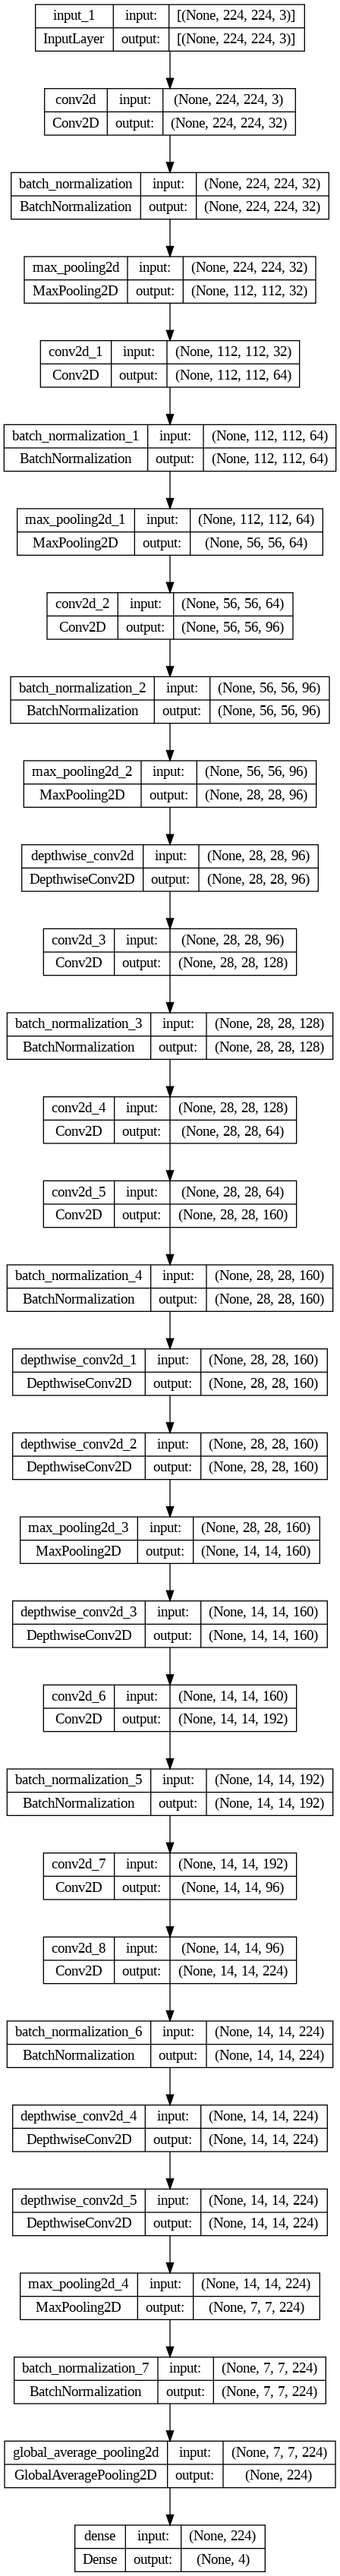

In [12]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(model, to_file='convnet.png', show_shapes=True,show_layer_names=True)
Image(filename='convnet.png')


In [13]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=METRICS
)

In [14]:
def lr_schedule(epoch,learning_rate):
  if epoch <7:
    return learning_rate
  else:
    return 0.95*learning_rate

lr_scheduler = LearningRateScheduler(lr_schedule)

In [15]:
callbacks = [
    ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)#,
    # EarlyStopping(monitor="val_loss", patience=10, verbose=1, restore_best_weights=True)
]

In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[callbacks, lr_scheduler],
        verbose=1
    #  , class_weight=class_weights
)


Epoch 1/20
93/93 [==============================] - ETA: 0s - loss: 1.0406 - accuracy: 0.6929 - precision: 0.7712 - recall: 0.3918 - auc: 0.8313 - f1_score: 0.6929Failed to load /kaggle/input/lung-cancer-dicom/imbalanced_dataset/A/A_c878b58e7b6f44808a7fd6447692dd50.dcm: The number of bytes of pixel data is less than expected (136218 vs 524288 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect

Epoch 1: val_accuracy improved from -inf to 0.65737, saving model to best_model.keras
93/93 [==============================] - 285s 3s/step - loss: 1.0406 - accuracy: 0.6929 - precision: 0.7712 - recall: 0.3918 - auc: 0.8313 - f1_score: 0.6929 - val_loss: 0.9813 - val_accuracy: 0.6574 - val_precision: 0.6574 - val_recall: 0.6574 - val_auc: 0.8415 - val_f1_score: 0.6574 - lr: 5.0000e-04
Epoch 2/20
93/93 [==============================] - ETA: 0s - loss: 0.7301 - accuracy: 0.7308 - precision: 0.7816 - recall: 0.6529 - auc: 0.9112

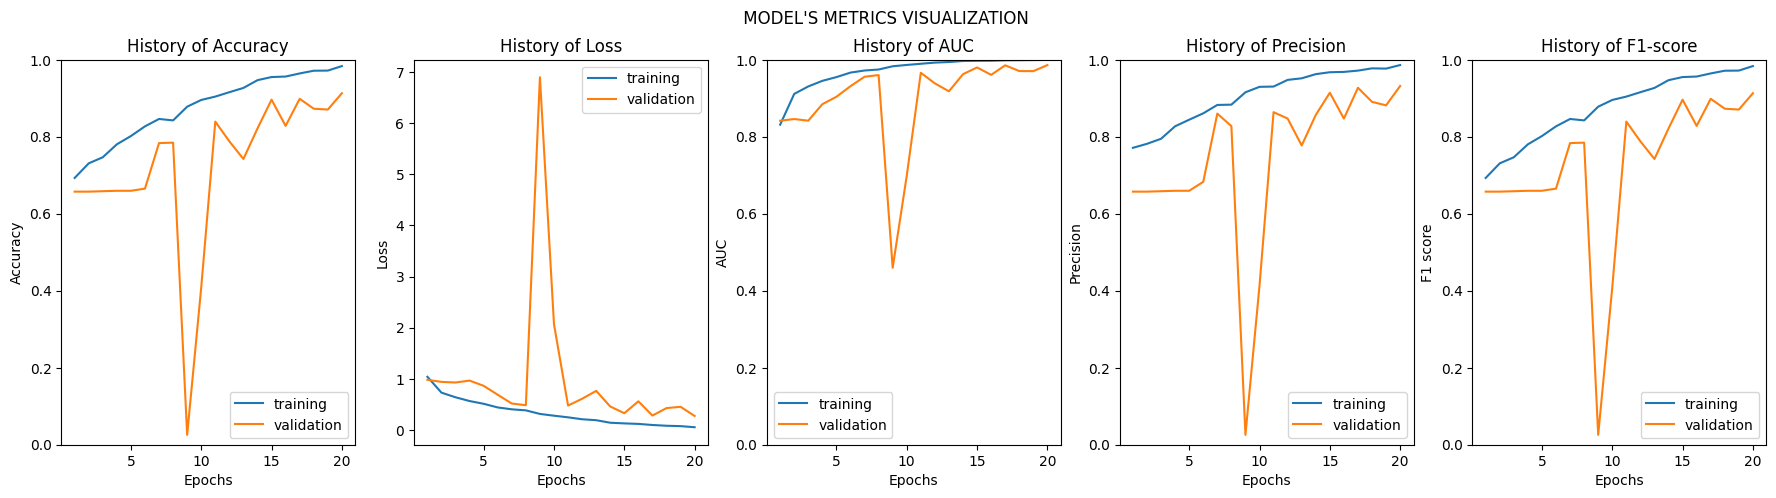

In [17]:
def Train_Val_Plot(acc, val_acc, loss, val_loss, auc, val_auc, precision, val_precision, f1, val_f1):

    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    # Rescale the y-axis for accuracy, auc, precision, and f1
    rescale_factor = 0  # Adjust this factor to control the rescaling

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0, 1.0])
    ax1.legend(['training', 'validation'])

    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])

    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.set_ylim([rescale_factor, 1.0])
    ax3.legend(['training', 'validation'])

    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.set_ylim([rescale_factor, 1.0])
    ax4.legend(['training', 'validation'])

    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.set_ylim([rescale_factor, 1.0])
    ax5.legend(['training', 'validation'])

    plt.show()

# Example usage:
Train_Val_Plot(history.history['accuracy'], history.history['val_accuracy'],
               history.history['loss'], history.history['val_loss']
               ,
               history.history['auc'], history.history['val_auc'],
               history.history['precision'], history.history['val_precision'],
               history.history['f1_score'], history.history['val_f1_score'])

In [18]:
model.evaluate(test_generator)

20/20 [==============================] - 16s 787ms/step - loss: 0.2887 - accuracy: 0.9016 - precision: 0.9192 - recall: 0.8891 - auc: 0.9856 - f1_score: 0.9016


[0.2887111008167267,
 0.901562511920929,
 0.9192245602607727,
 0.8890625238418579,
 0.9855549931526184,
 0.901562511920929]

In [19]:
X_test, y_test = [], []
for i in range(len(test_generator)):
    batch_X, batch_y = test_generator[i]
    X_test.append(batch_X)
    y_test.append(batch_y)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert the one-hot encoded predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert the one-hot encoded true labels to class labels
y_true_classes = np.argmax(y_test, axis=1)

# Create a classification report
report = classification_report(y_true_classes, y_pred_classes)

# Print the classification report
print(report)

20/20 [==============================] - 15s 719ms/step
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       424
           1       0.87      0.68      0.76        68
           2       1.00      0.29      0.44         7
           3       0.96      0.77      0.85       141

    accuracy                           0.90       640
   macro avg       0.93      0.68      0.75       640
weighted avg       0.90      0.90      0.90       640



In [20]:
# Class names in order of label_to_index mapping
class_names = ['Adenocarcinoma', 'Small Cell Carcinoma', 'Large Cell Carcinoma', 'Squamous Cell Carcinoma']

# Classification report with class names
report = classification_report(y_true_classes, y_pred_classes, target_names=class_names, digits=3)

print(report)

                         precision    recall  f1-score   support

         Adenocarcinoma      0.892     0.993     0.940       424
   Small Cell Carcinoma      0.868     0.676     0.760        68
   Large Cell Carcinoma      1.000     0.286     0.444         7
Squamous Cell Carcinoma      0.956     0.766     0.850       141

               accuracy                          0.902       640
              macro avg      0.929     0.680     0.749       640
           weighted avg      0.905     0.902     0.896       640



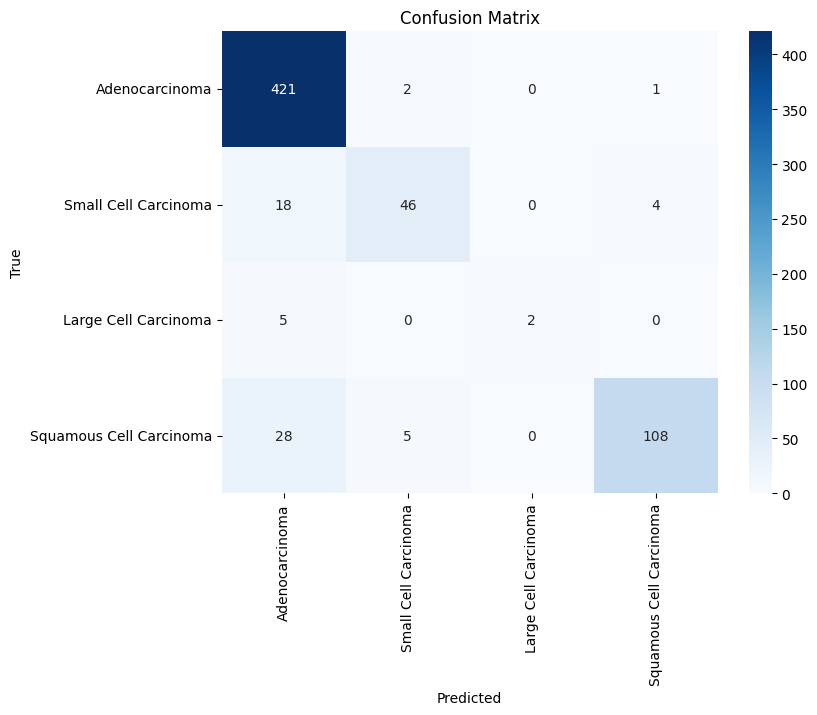

In [21]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()